# 4PL model for Automated ELISA Analysis

This notebook demonstrates a Python-based four-parameter logistic (4PL) model developed to automate quantitative ELISA result calculations.

The workflow was designed to reduce manual data processing, standardize the analysis, and improve the consistency and reproducibility of reported results. This notebook uses the synthetic dataset generated by generate_testset.py.

### Objectives

The automated workflow was designed to:

 - Reduce manual data processing and result calculation time
 - Standardize the curve-fitting and calculation workflow
 - Generate calibration curves automatically
 - Back-calculate sample concentrations from measured OD values
 - Evaluate run validity against predefined QC acceptance criteria
 
### Workflow

The analysis consists of the following steps:

1. Import the ELISA plate export and isolate the OD data block for the selected channel.
2. Calculate average OD values from duplicate measurements and blank-correct using the average blank OD.
3. Fit a four-parameter logistic (4PL) calibration curve.
4. Calculate sample concentrations from measured OD values and summarize the calculated results.
5. Back-calculate sample concentrations from measured OD values and summarize the results.
6. Evaluate results against predefined QC acceptance thresholds.
7. Limitations and Future Development.

### Packages Used

In [1]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pathlib import Path
import re

### QC Thresholds

In [2]:
# QC thresholds
R2_PASS_THRESHOLD = 0.98
STD_RECOVERY_LOW = 75.0
STD_RECOVERY_HIGH = 125.0
CV_PASS_THRESHOLD = 25.0
MIN_OD_FOR_CV_CHECK = 0.05

The QC thresholds used here are intentionally more conservative than a typical +/- 50% acceptance criterion. They serve as automated screening thresholds that flag runs for further review, rather than as definitive assay acceptance criteria.

### 1. Importing Workbook

In [3]:
#Loanding ELISA data from selected OD
def load_workbook_grid(workbook_path, wanted_od):
    
    workbook_path = Path(workbook_path)
    workbook = pd.ExcelFile(workbook_path)

    possible_sheets = ["Results by plate","Results","Sheet1","Results_by_plate"]
    selected_sheet = next((sheet for sheet in possible_sheets if sheet in workbook.sheet_names), None)

    df = pd.read_excel(workbook_path, sheet_name=selected_sheet, header=None)
    matches = df.iloc[:, 0].astype(str).str.strip().str.lower()
    matches = matches[matches == wanted_od.strip().lower()]
    wanted_idx = matches.index[0]

    new_df = df.iloc[wanted_idx:].reset_index(drop=True)

    # Remove the first two rows and first two columns
    new_df = new_df.iloc[2:, 2:].reset_index(drop=True)
    return new_df

excel_path = Path(r"C:\Users\Julia\VSCodePythonProject\synthetic_elisa_plate.xlsx")
wanted_od = "OD(550)"
df = load_workbook_grid(excel_path,wanted_od)
df

,2,3,4,5,6,7,8,9,10,11,12,13
0,2.999,2.970,1.921,1.913,1.626,1.522,2.097,2.310,0.555,0.596,0.023,0.025
1,2.636,2.651,0.265,0.259,2.955,2.829,1.849,1.930,1.65,1.844,0.026,0.025
2,2.331,2.339,2.983,2.995,2.55,2.432,1.888,2.024,0.537,0.549,0.022,0.020
3,1.711,1.703,2.27,2.355,1.131,1.212,1.126,1.062,2.33,2.427,0.029,0.022
4,0.973,1.035,2.72,2.650,2.964,2.795,0.157,0.153,1.621,1.514,0.028,0.021
5,0.54,0.581,1.301,1.220,2.916,2.963,1.61,1.527,1.303,1.341,0.027,0.025
6,0.287,0.290,3.763,3.259,1.286,1.270,0.773,0.743,1.07,1.136,0.024,0.022
7,0.145,0.143,3.068,3.233,1.028,1.027,1.471,1.495,2.369,2.032,1.67,1.465
8,"STD 32,0000",NaN,A1 Assay,NaN,A2 Assay,NaN,A3 Assay,NaN,A4 Assay,NaN,blank,NaN
9,"STD 16,0000",NaN,A1 Assay 5x,NaN,A2 Assay 5x,NaN,A3 Assay 5x,NaN,A4 Assay 5x,NaN,blank,NaN


### 2. Preprocess Raw Data

Standard and blank wells are identified from the label data. The function first calculates the average blank OD and subtracts it from all standards and samples. It then calculates the average OD across duplicate wells, since all samples in this example are measured in duplicate.

In [4]:
def find_blank_wells(label_data):
    mask = label_data.apply(lambda col: col.astype(str).str.strip().str.lower().str.contains("blank", na=False))

    return [(row, col) for col in label_data.columns for row in range(len(label_data)) if mask[col].iloc[row]]

def find_standard_columns(label_data):
    return [col for col in label_data.columns if (pd.notna(label_data[col].iloc[0]) 
                                                  and str(label_data[col].iloc[0]).strip().lower().startswith("std"))]

def four_pl(logx, A, B, logEC50, D):
    return D + (A - D) / (1 + 10 ** ((logEC50 - logx) * B))

In [5]:
def preprocess_elisa_data(df):
    # First 8 rows contain OD measurements
    od_data = df.iloc[:8].apply(pd.to_numeric, errors="coerce")

    # Remaining rows contain labels
    label_data = df.iloc[8:].copy()

    # Find blanks
    blank_wells = find_blank_wells(label_data)
    blank_values = [od_data[col].iloc[row] for row, col in blank_wells]
    blank_avg = np.nanmean(blank_values)
    print(f"Average blank OD: {blank_avg:.6f}")

    # Blank correction
    od_corrected = od_data - blank_avg

    # Identify completely blank columns
    blank_counts = pd.Series([col for _, col in blank_wells]).value_counts()
    fully_blank_cols = blank_counts[blank_counts == len(od_data)].index

    # Keep all non-blank columns
    sample_cols = [col for col in od_corrected.columns if col not in fully_blank_cols]

    # Average duplicates + CV
    averages = {}
    cvs = {}

    for i in range(0, len(sample_cols), 2):
        name = f"Sample_{i // 2 + 1}"
        pair = od_corrected[sample_cols[i:i + 2]]
        mean = pair.mean(axis=1)
        cv = (pair.std(axis=1, ddof=1) / mean.abs() * 100)

        averages[name] = mean
        cvs[name] = cv

    corrected_df = pd.DataFrame(averages)
    cv_df = pd.DataFrame(cvs)

    print("\nBlank-corrected duplicate averages:")
    display(corrected_df)

    return corrected_df, cv_df, label_data

corrected_df, cv_df, label_data = preprocess_elisa_data(df)

STD_START = 32
STD_DILUTION = 0.5
N_STANDARDS = 8

standard_concentrations = np.array([STD_START * (STD_DILUTION ** i) for i in range(N_STANDARDS)])
std_cols_raw = find_standard_columns(label_data)

columns = list(df.columns)

std_sample_names = list(dict.fromkeys(f"Sample_{columns.index(col) // 2 + 1}" for col in std_cols_raw))

y = np.concatenate([corrected_df[name].iloc[:8].to_numpy() for name in std_sample_names])
x = standard_concentrations.copy()

def fit_4pl(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    logx = np.log10(x)
    p0 = [np.max(y), 1.2, np.log10(np.median(x)), np.min(y)]
    parameters, _ = curve_fit(four_pl, logx, y, p0=p0, maxfev=100000)

    A, B, logEC50, D = parameters

    y_pred = four_pl(logx, A, B, logEC50, D)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot

    return A, B, logEC50, D, r2, x, y


A, B, logEC50, D, r2, x_fit, y_fit = fit_4pl(x,y)

C = 10 ** logEC50

print(f"Top asymptote (A): {A:.4f}")
print(f"Slope (B): {B:.4f}")
print(f"EC50 (C): {C:.4f} ng/mL")
print(f"Bottom asymptote: {D:.4f}")
print(f"R2: {r2:.5f}")

Average blank OD: 0.025571

Blank-corrected duplicate averages:


,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6
0,2.958929,1.891429,1.548429,2.177929,0.549929,-0.001571
1,2.617929,0.236429,2.866429,1.863929,1.721429,-0.000071
2,2.309429,2.963429,2.465429,1.930429,0.517429,-0.004571
3,1.681429,2.286929,1.145929,1.068429,2.352929,-0.000071
4,0.978429,2.659429,2.853929,0.129429,1.541929,-0.001071
5,0.534929,1.234929,2.913929,1.542929,1.296429,0.000429
6,0.262929,3.485429,1.252429,0.732429,1.077429,-0.002571
7,0.118429,3.124929,1.001929,1.457429,2.174929,1.541929


Top asymptote (A): 3.1041
Slope (B): 1.2606
EC50 (C): 3.6156 ng/mL
Bottom asymptote: 0.0189
R2: 0.99882


### 3. Fit Standard Curve

The blank-corrected standard concentrations and corresponding OD measurements are used to fit a four-parameter logistic (4PL) calibration model.

The 4PL model describes the sigmoidal relationship between analyte concentration and assay response. The four parameters represent the upper asymptote, slope, inflection point, and lower asymptote.

The fitted parameters are subsequently used both to generate the calibration curve and to back-calculate concentrations for unknown samples.

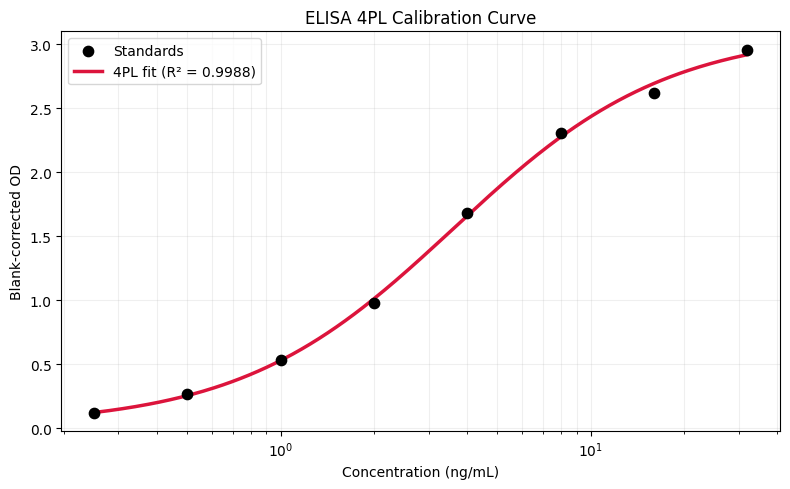

Plot saved to: C:\Users\Julia\Portfolio for Nordeo Quantitative Risk analysis\4 PL model\ELISA_4PL_calibration_curve.png


In [6]:
def plot_fit(x_fit, y_fit, A, B, logEC50, D, r2):

    x_smooth = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 300)
    y_smooth = four_pl(np.log10(x_smooth), A, B, logEC50, D)

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(x_fit, y_fit, color="black", s=55, zorder=5, label="Standards")

    ax.plot(x_smooth, y_smooth, color="crimson", linewidth=2.5,label=f"4PL fit (R² = {r2:.4f})")

    ax.set_xscale("log")
    ax.set_xlabel("Concentration (ng/mL)")
    ax.set_ylabel("Blank-corrected OD")
    ax.set_title("ELISA 4PL Calibration Curve")
    ax.grid(True, which="both", alpha=0.2)
    ax.legend()

    plt.tight_layout()

    return fig

plot_path = Path("ELISA_4PL_calibration_curve.png")

fig = plot_fit(x_fit, y_fit, A, B, logEC50, D, r2)

fig.savefig(
    plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Plot saved to: {plot_path.resolve()}")



### Curve Fit Assessment

The fitted curve is assessed using the estimated 4PL parameters, the coefficient of determination ($R^2$), and visual comparison between the fitted curve and the experimental standard points.

$R^2$ indicates how closely the model describes the observed standard responses, but visual inspection remains important for identifying systematic deviations that may not be apparent from $R^2$ alone.

$R^2$ is used as one automated indicator of curve fit quality, but on its own it is not sufficient to establish calibration validity. Standard recovery, residual behavior, replicate precision, and the quantitative range should also be considered.

### 4. Calculate Sample Concentrations

The sample data are arranged as duplicate OD measurements, with the corresponding sample information (name, timepoint, dilution) stored separately in the label rows.

For each sample pair, the duplicate OD measurements are averaged to obtain a single assay response. Labels are then parsed to extract the sample name, timepoint, and dilution factor.

The fitted 4PL parameters are used to back-calculate the concentration corresponding to each measured OD value, which is then multiplied by the sample-specific dilution factor to obtain the final reported concentration.

>Note: When a measured OD falls outside the quantitative range of the fitted curve, reliable back-calculation is not possible, and the result is reported as NaN. In a practical assay workflow, such samples would require reassessment, for example, by re-testing at an alternative dilution.

In [7]:
def calculate_results(df, corrected_df, label_data, A, B, logEC50, D):
    results = []
    columns = list(df.columns)
    C = 10 ** logEC50

    for p in range(0, len(columns), 2):
        col = columns[p]
        sample_col = f"Sample_{p // 2 + 1}"
        for i, label in enumerate(label_data[col].iloc[:8]):
            label_str = str(label).strip()
            # Parse dilution
            dilution_match = re.search(r"(\d+(?:\.\d+)?)\s*x\b", label_str, re.IGNORECASE)
            dilution = (float(dilution_match.group(1)) if dilution_match else 1.0)
            # Parse sample name and type
            parts = label_str.split(maxsplit=1)

            sample_name = parts[0]
            sample_type = parts[1] if len(parts) > 1 else ""

            if dilution_match:
                sample_type = sample_type.replace(dilution_match.group(0), "")

            sample_type = re.sub(r"\s+", " ", sample_type).strip()

            # OD
            y = corrected_df[sample_col].iloc[i]

            # Back-calculate concentration
            if pd.isna(y):
                concentration = np.nan

            elif D < y < A:
                ratio = (A - D) / (y - D) - 1
                concentration = (C * ratio ** (-1 / B) if ratio > 0 else np.nan)
            else:
                concentration = np.nan
            # Correct for dilution
            calculated = (concentration * dilution if pd.notna(concentration) else np.nan)

            results.append({
                "Sample": sample_name,
                "Sample Type": sample_type,
                "Dilution": dilution,
                "OD": y,
                "_raw_concentration_internal": concentration,
                "Concentration (ng/mL)": calculated,
                "Concentration (µg/mL)": (calculated / 1000 if pd.notna(calculated) else np.nan)
            })

    return pd.DataFrame(results)

results_df = calculate_results(df, corrected_df, label_data, A, B, logEC50, D)
display(results_df)

,Sample,Sample Type,Dilution,OD,_raw_concentration_internal,Concentration (ng/mL),Concentration (µg/mL)
0,STD,"32,0000",1.0,2.958929,39.311193,39.311193,0.039311
1,STD,"16,0000",1.0,2.617929,13.667295,13.667295,0.013667
2,STD,"8,0000",1.0,2.309429,8.372949,8.372949,0.008373
3,STD,"4,0000",1.0,1.681429,4.091309,4.091309,0.004091
4,STD,"2,0000",1.0,0.978429,1.923865,1.923865,0.001924
5,STD,"1,0000",1.0,0.534929,1.012079,1.012079,0.001012
6,STD,"0,5000",1.0,0.262929,0.515918,0.515918,0.000516
7,STD,"0,2500",1.0,0.118429,0.243555,0.243555,0.000244
8,A1,Assay,1.0,1.891429,5.103413,5.103413,0.005103
9,A1,Assay,5.0,0.236429,0.467505,2.337523,0.002338


### Result

The resulting table provides the calculated concentration for each sample after accounting for the sample-specific dilution factor. This structure can be used for downstream comparison of concentrations across samples and timepoints.

> **Note:** When a measured OD falls below the lower asymptote of the fitted curve or outside the quantitative range of the calibration curve, reliable back-calculation is not possible and the result is reported as `NaN`. In a practical assay workflow, such samples would require reassessment, for example by testing an appropriate alternative dilution.

## 5. QC Table

In [8]:
def generate_qc_table(r2, results_df, cv_df, x, corrected_df):
    rows = []
    
    # Helper for PASS / WARNING / FAIL
    def qc_status(passed, total):
        if total == 0:
            return "FAIL"
        if passed == total:
            return "PASS"
        if passed / total >= 0.75:
            return "WARNING"
        return "FAIL"
    
    # 4PL curve R²
    rows.append(["4PL Curve R²", f"{r2:.4f}", f">= {R2_PASS_THRESHOLD}", "PASS" if r2 >= R2_PASS_THRESHOLD else "FAIL"])
    
    # Standard recovery
    std = results_df[results_df["Sample"].astype(str).str.upper().str.startswith("STD")].copy()
    std["Nominal"] = pd.to_numeric(std["Sample Type"].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    std["Recovery %"] = (std["Concentration (ng/mL)"] / std["Nominal"] * 100)
    std = std.dropna(subset=["Recovery %"])

    if len(std) > 0:
        passing = std["Recovery %"].between(STD_RECOVERY_LOW, STD_RECOVERY_HIGH)
        rows.append(["Standard Recovery", f"{passing.sum()}/{len(std)} passing", f"{STD_RECOVERY_LOW}-{STD_RECOVERY_HIGH}%",
            qc_status(passing.sum(), len(std))])
        # Lowest standard
        lowest = std.loc[std["Recovery %"].idxmin()]
        rows.append(["Lowest Standard Recovery", f"{lowest['Recovery %']:.1f}% ({lowest['Nominal']:g} ng/mL)",
            f"{STD_RECOVERY_LOW}-{STD_RECOVERY_HIGH}%",
            ("PASS" if STD_RECOVERY_LOW <= lowest["Recovery %"] <= STD_RECOVERY_HIGH else "FAIL")])
    else:
        rows.append(["Standard Recovery", "No standards found", f"{STD_RECOVERY_LOW}-{STD_RECOVERY_HIGH}%", "FAIL"])
        
    # Duplicate CV
    cv = cv_df.to_numpy().ravel()
    od = corrected_df.to_numpy().ravel()
    valid = (~np.isnan(cv) & ~np.isnan(od) & (od >= MIN_OD_FOR_CV_CHECK))
    cv = cv[valid]
    if len(cv) > 0:
        passing = cv <= CV_PASS_THRESHOLD
        rows.append(["Duplicate CV", f"{passing.sum()}/{len(cv)} passing", f"<= {CV_PASS_THRESHOLD}%",
                     qc_status(passing.sum(), len(cv))])
        max_cv = cv.max()
        rows.append(["Maximum Duplicate CV", f"{max_cv:.1f}%", f"<= {CV_PASS_THRESHOLD}%",
            "PASS" if max_cv <= CV_PASS_THRESHOLD else "FAIL"])
    else:
        rows.append(["Duplicate CV", "No valid measurements", f"<= {CV_PASS_THRESHOLD}%", "FAIL"])
        
    # Calibration range
    samples = results_df[~results_df["Sample"].astype(str).str.upper().str.startswith("STD")
                        & (results_df["Sample"].astype(str).str.upper() != "CONTROL")
                        & (results_df["Sample"].astype(str).str.upper() != "BLANK")].copy()

    x_min = min(x)
    x_max = max(x)

    if len(samples) > 0:
        in_range = samples["_raw_concentration_internal"].between(x_min, x_max)
        in_range = in_range.fillna(False)

        rows.append(["Samples Within Calibration Range", f"{in_range.sum()}/{len(samples)}", f"{x_min:g}-{x_max:g} ng/mL",
            qc_status(in_range.sum(), len(samples))])
    else:
        rows.append(["Samples Within Calibration Range", "No samples", f"{x_min:g}-{x_max:g} ng/mL", "PASS"])
        __
    # Overall status
    statuses = [row[3] for row in rows]

    overall = ("FAIL" if "FAIL" in statuses else "WARNING" if "WARNING" in statuses else "PASS")
    rows.append(["OVERALL RUN STATUS", "", "", overall])
    # Create table
    qc_table = pd.DataFrame(rows,columns=["QC Check", "Result", "Limit", "Status"])
    # Styling
    colors = {"PASS": ("background-color: #c6efce;" "color: #006100;" "font-weight: bold;"),
              "WARNING": ("background-color: #ffeb9c;" "color: #9c6500;" "font-weight: bold;"),
              "FAIL": ("background-color: #ffc7ce;" "color: #9c0006;" "font-weight: bold;")}
    def color_status(value):
        return colors.get(value, "")
    
    return (qc_table.style.applymap(color_status, subset=["Status"]).set_properties(**{"text-align": "center",
            "padding": "6px"}).set_table_styles([{"selector": "th", "props": [("background-color", "#404040"),
                    ("color", "white"), ("font-weight", "bold"), ("text-align", "center")]}]))

qc_table = generate_qc_table(r2,results_df,cv_df,x,corrected_df)
qc_table

,QC Check,Result,Limit,Status
0,4PL Curve R²,0.9988,>= 0.98,PASS
1,Standard Recovery,8/8 passing,75.0-125.0%,PASS
2,Lowest Standard Recovery,85.4% (16 ng/mL),75.0-125.0%,PASS
3,Duplicate CV,41/41 passing,<= 25.0%,PASS
4,Maximum Duplicate CV,11.0%,<= 25.0%,PASS
5,Samples Within Calibration Range,29/32,0.25-32 ng/mL,WARNING
6,OVERALL RUN STATUS,,,WARNING


The QC summary indicates that the run meets the defined criteria for curve fit, standard recovery, and duplicate precision. However, one sample falls outside the calibration range, resulting in an overall WARNING status and indicating that the affected result should be reviewed.

### 6. Limitations and Further Development

This implementation demonstrates an automated ELISA analysis workflow using synthetic data. In a production assay environment, additional validation would be required, including:

 - Residual analysis
 - Weighting strategies for calibration curve fitting
 - Acceptance criteria for individual standards
 - Assessment of plate effects and inter-run variability
 - Assay-specific limits of quantification

Future improvements could include automated residual analysis, weighted 4PL fitting, more granular standard acceptance criteria, automated detection of plate effects, and generation of machine-readable QC reports.

Results could also be appended to a master dataset (e.g. a consolidated CSV or database) across runs, making it easier to compare results between assays over time. This historical dataset could then be used to monitor assay drift and, longer term, to build a model capable of flagging drift automatically rather than relying on manual review.